# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163


1. Morphological Operations
    For each morphological method below,
    Find one image from the internet in which the effect of the method is clearly visible, then apply the method:
        (a) Dilation
        (b) Erosion
        (c) Opening
        (d) Closing
        (e) Morphological Gradient

    For each operator:
      - Show the original image
      - Choose an appropriate structuring element
      (e.g., cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
      - Show the processed image
      - Explain in 3–5 sentences why the result looks the way it does

2. Morphology Applications
    (a) License Plate Character Extraction

      - Find an image of a vehicle license plate

      - Use a combination of morphological operations
      (e.g., closing → opening → gradient → thresholding)

      - Extract and isolate the individual characters

      - Display:
        - Preprocessing steps
        - Intermediate morphology results
        - Final segmented characters

    (b) Storefront Signboard Text Extraction

      - Find a picture of a shop sign / storefront

      - Combine morphology + thresholding to:
        - Remove background clutter
        - Highlight the text regions
        - Extract meaningful information such as:
        Shop name, phone number, address, promotions, etc.

      - Document your full pipeline

3. Image Inpainting

    (a) Mask Generation using Morphology + Diffusion-Based Inpainting

      - Use dilation, erosion, or morphological closing to generate a binary mask
      (e.g., detecting defects, noise, unwanted objects)

      - Apply diffusion-based inpainting and then using OpenCV's PDE-based Telea or NS method

      - Show:
        - Image
        - Mask
        - Final inpainted result
        - Discussion

    (b) Re-implement the method from the paper
    "Region Filling and Object Removal by Exemplar-Based Image Inpainting" (Criminisi et al., 2004)

      - Implement the exemplar-based pipeline:
        - Priority computation
        $$P(p)=C(p)D(p)$$
        - Patch search
        - Patch replacement
        - Update confidence map

      - Explain the full algorithm:
          - Confidence term
          - Data term (isophote direction)
          - Patch matching
          - Boundary filling strategy

      - Choose an image with missing regions or objects to remove
          → Compare your result vs OpenCV inpainting.

    (c) Implement One Additional Inpainting Method (Beyond the Above Two)
    Choose one of the following categories and implement one method:
    ```
        - Local Statistical Models
          - Gaussian Mixture Models (GMM)
          - Markov Random Fields (MRF)
        - Patch-Based Methods
          - PatchMatch
          - Texture synthesis methods
        - Sparse Representation / Dictionary Learning
          - K-SVD Inpainting
          - Wavelet / Curvelet / Shearlet domain inpainting
        - CNN-Based Inpainting
          - Partial Convolution
          - Gated Convolution
          - Context Encoder (AE-based)
        - GAN-Based Inpainting
          - DeepFill v1/v2
          - EdgeConnect
          - StructureFlow
        - Transformer-Based Inpainting
          - MAT (Masked Autoencoder Transformer)
          - ViT-Inpainting models
        - Diffusion-Based Inpainting (2022–2025)
          - LaMa
          - RePaint
          - Stable Diffusion Inpainting
          - DALL·E 2 / 3 inpainting
          - SDXL Inpainting
          - SDE-based diffusion inpainting
    ```
    - For your chosen method:
      - Explain the mathematical idea
      - Implement a working minimal example
      (Open-source models allowed)
      - Compare with exemplar-based and diffusion-inpainting


Import Libs

In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import time
import gdown
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

from cv2 import imwrite, imread
from skimage import data, exposure, img_as_float, img_as_ubyte
from skimage import exposure
from skimage import io
from skimage.exposure import match_histograms
from scipy import ndimage
from skimage import feature
from pylab import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_local
from scipy.fftpack import dct, idct
from skimage.color import rgb2lab
from skimage.filters import laplace
from scipy.ndimage.filters import convolve


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5176\4065570148.py:26: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve


In [3]:
def Image3Dto2D(image):
    """
    Convert a 3D image (color) to a 2D image (grayscale).

    Parameters:
        image (ndarray): Input image, which can be 2D (grayscale) or 3D (color).

    Returns:
        image_2D (ndarray): Grayscale image as a 2D array.
    """
    # Check if the image has at least 3 dimensions (color image)
    if len(image.shape) >= 3:
        # Convert the 3D color image to grayscale using OpenCV's cvtColor function
        image_2D = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        # If the image is already 2D (grayscale), create a copy of it
        image_2D = image.copy()

    return image_2D


## 1. Morphological Operations
  - For each morphological method below,
    Find one image from the internet in which the effect of the method is clearly visible, then apply the method:
        (a) Dilation
        (b) Erosion
        (c) Opening
        (d) Closing
        (e) Morphological Gradient

  - For each operator:
      - Show the original image
      - Choose an appropriate structuring element
      (e.g., cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
      - Show the processed image
      - Explain in 3–5 sentences why the result looks the way it does

Getting Image

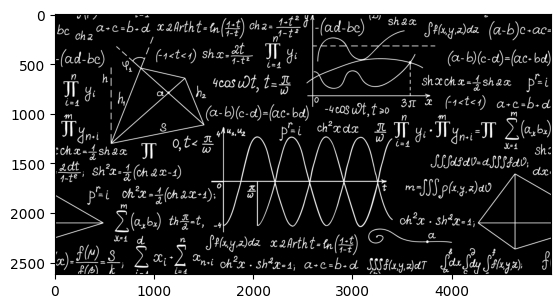

In [4]:
newImg_BGR = cv2.imread('mathematics.jpg')  
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)

plt.imshow(newImg_RGB)
# plt.imshow(newImg2_RGB)


Convert the image to grayscale.

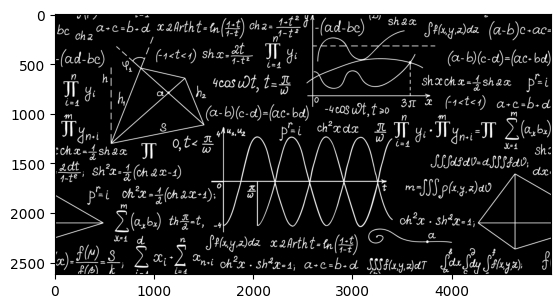

In [5]:
newImg_Gray = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2GRAY)
plt.imshow(newImg_Gray, cmap='gray')

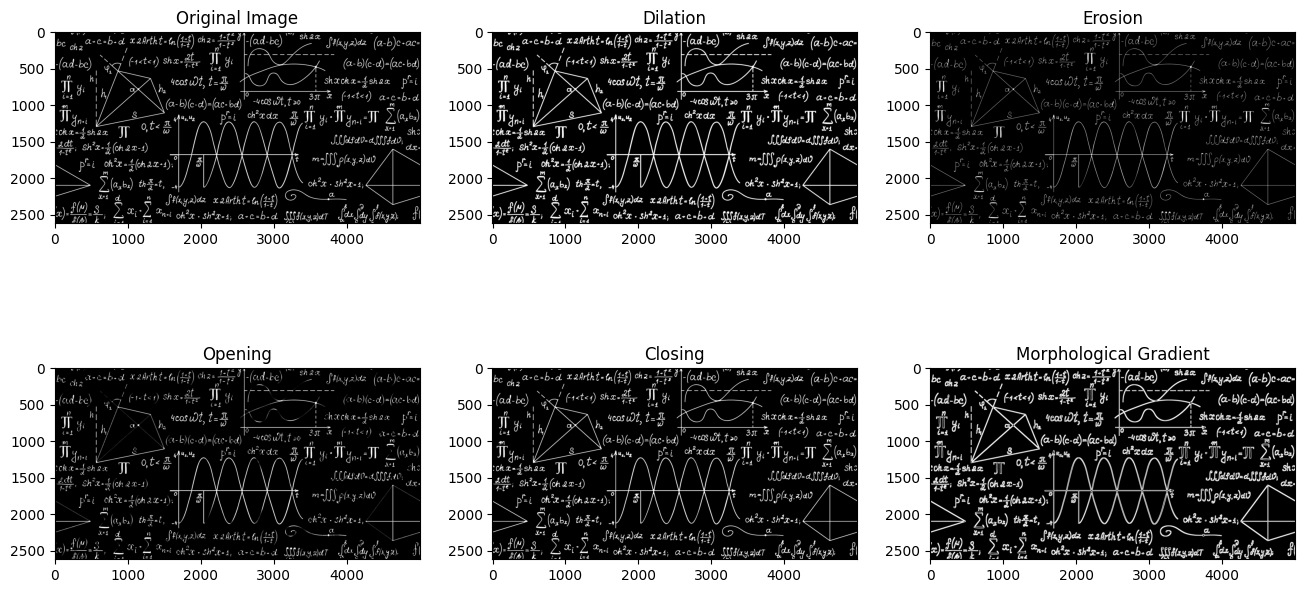

In [6]:
# ## 1. Morphological Operations
#   - For each morphological method below,
#     Find one image from the internet in which the effect of the method is clearly visible, then apply the method:
#         (a) Dilation
#         (b) Erosion
#         (c) Opening
#         (d) Closing
#         (e) Morphological Gradient

#   - For each operator:
#       - Show the original image
#       - Choose an appropriate structuring element
#       (e.g., cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
#       - Show the processed image
#       - Explain in 3–5 sentences why the result looks the way it does

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
kernel2 = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
dilation = cv2.dilate(newImg_Gray, kernel, iterations=1)
erosion = cv2.erode(newImg_Gray, kernel, iterations=1)
opening = cv2.morphologyEx(newImg_Gray, cv2.MORPH_OPEN, kernel2)
closing = cv2.morphologyEx(newImg_Gray, cv2.MORPH_CLOSE, kernel2)
morph_gradient = cv2.morphologyEx(newImg_Gray, cv2.MORPH_GRADIENT, kernel2)

plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(newImg_Gray, cmap='gray')
plt.subplot(2, 3, 2)
plt.title('Dilation')
plt.imshow(dilation, cmap='gray')
plt.subplot(2, 3, 3)
plt.title('Erosion')
plt.imshow(erosion, cmap='gray')
plt.subplot(2, 3, 4)
plt.title('Opening')
plt.imshow(opening, cmap='gray')
plt.subplot(2, 3, 5)
plt.title('Closing')
plt.imshow(closing, cmap='gray')
plt.subplot(2, 3, 6)
plt.title('Morphological Gradient')
plt.imshow(morph_gradient, cmap='gray')
plt.show()

# - Explain in 3–5 sentences each transform why the result looks the way it does
# Dilation: This operation adds pixels to the boundaries of objects in an image. The structuring element used here is an ellipse, which causes the bright regions to expand outward, filling in small holes and connecting nearby objects. This is particularly useful for enhancing features in binary images.
# Erosion: This operation removes pixels from the boundaries of objects. Using the same elliptical structuring element, erosion shrinks bright regions, effectively removing small noise and separating connected objects. It is useful for eliminating small artifacts in images.
# Opening: This operation is a combination of erosion followed by dilation. It is effective for removing small objects from the foreground while preserving the shape and size of larger objects. The rectangular structuring element helps to smooth the contours of objects and eliminate noise.
# Closing: This operation is the reverse of opening, consisting of dilation followed by erosion. It is useful for closing small holes and gaps in the foreground objects. The rectangular structuring element helps to fill in small dark regions within bright objects, enhancing their overall appearance.
# Morphological Gradient: This operation computes the difference between the dilation and erosion of an image.

Explain in 3–5 sentences each transform why the result looks the way it does


+ Dilation: <br>
    Phép giãn là quá trình thêm các điểm ảnh (pixel) vào ranh giới của các vùng sáng trong ảnh. Khi sử dụng phần tử cấu trúc dạng elip, các vùng sáng sẽ “nở” ra, làm cho các chi tiết nhỏ được lấp đầy và những vùng sáng gần nhau có thể dính lại với nhau. Phép này thường dùng để làm nổi bật các vùng sáng và kết nối các chi tiết bị đứt.

+ Dilation: <br>
    Phép co sẽ loại bỏ các điểm ảnh ở rìa của vùng sáng. Khi dùng cùng phần tử cấu trúc elip, ảnh sau xử lý sẽ làm cho vùng sáng bị thu nhỏ lại, giúp loại bỏ các nhiễu nhỏ và tách rời những vật thể gần nhau. Phép co thường được dùng để làm sạch ảnh hoặc loại bỏ các chi tiết không mong muốn.

+ Opening: <br>
    Phép mở là sự kết hợp của co trước rồi đến giãn. Quá trình này giúp xóa bỏ các vật thể nhỏ không đáng kể trong ảnh mà vẫn giữ nguyên hình dáng của các vật thể lớn. Với phần tử cấu trúc hình chữ nhật, phép mở giúp làm mịn biên dạng vật thể và giảm nhiễu hiệu quả.

+ Closing: <br>
    Phép đóng ngược lại với phép mở, tức là giãn trước rồi mới co. Kỹ thuật này giúp lấp đầy các lỗ nhỏ hoặc khe hở bên trong vật thể sáng. Khi dùng phần tử cấu trúc hình chữ nhật, nó làm cho các vùng sáng trở nên liền mạch hơn và cải thiện hình dạng tổng thể của vật thể.

+ Morphological Gradient: <br>  
    Phép gradient được tính bằng cách lấy hiệu giữa ảnh sau phép giãn và ảnh sau phép co. Kết quả thu được làm nổi bật viền của các vật thể trong ảnh, giúp xác định ranh giới giữa vùng sáng và tối rõ ràng hơn.


## 2. Morphology Applications
- (a) License Plate Character Extraction
    - Find an image of a vehicle license plate
    - Use a combination of morphological operations
    (e.g., closing → opening → gradient → thresholding)
    - Extract and isolate the individual characters
    - Display:
        - Preprocessing steps
        - Intermediate morphology results
        - Final segmented characters

- (b) Storefront Signboard Text Extraction
    - Find a picture of a shop sign / storefront
    - Combine morphology + thresholding to:
        - Remove background clutter
        - Highlight the text regions
        - Extract meaningful information such as:
        Shop name, phone number, address, promotions, etc.
    - Document your full pipeline

- (a) License Plate Character Extraction
    - Find an image of a vehicle license plate
    - Use a combination of morphological operations
    (e.g., closing → opening → gradient → thresholding)
    - Extract and isolate the individual characters
    - Display:
        - Preprocessing steps
        - Intermediate morphology results
        - Final segmented characters

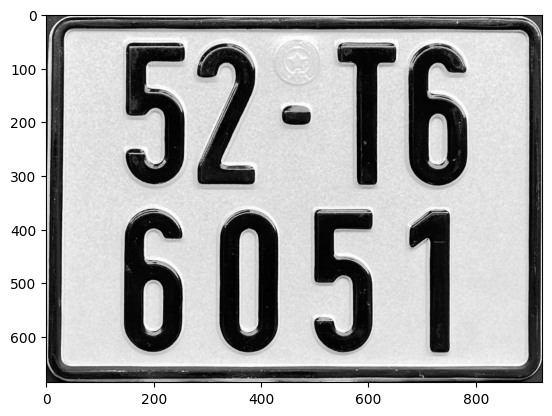

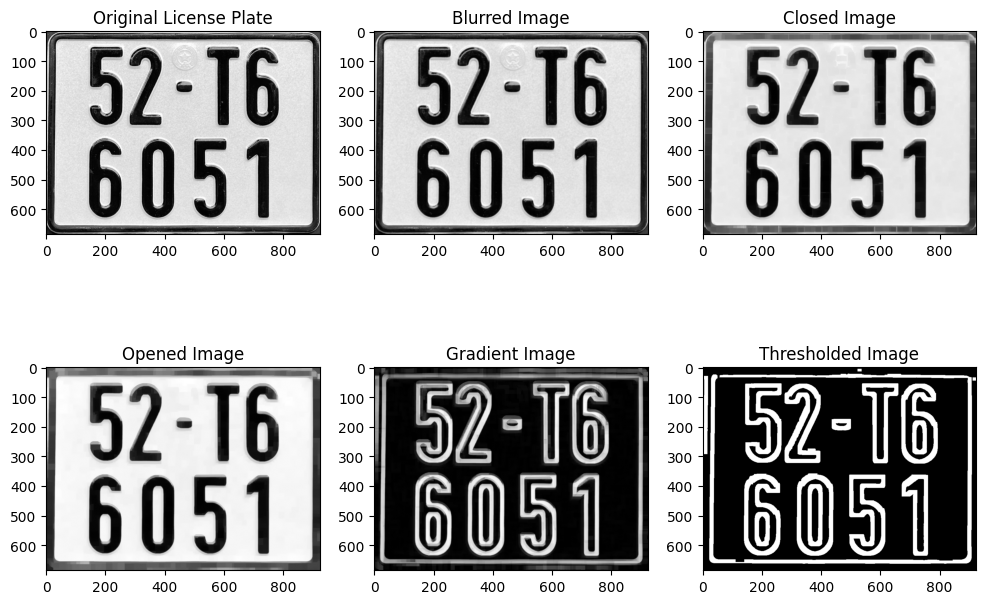

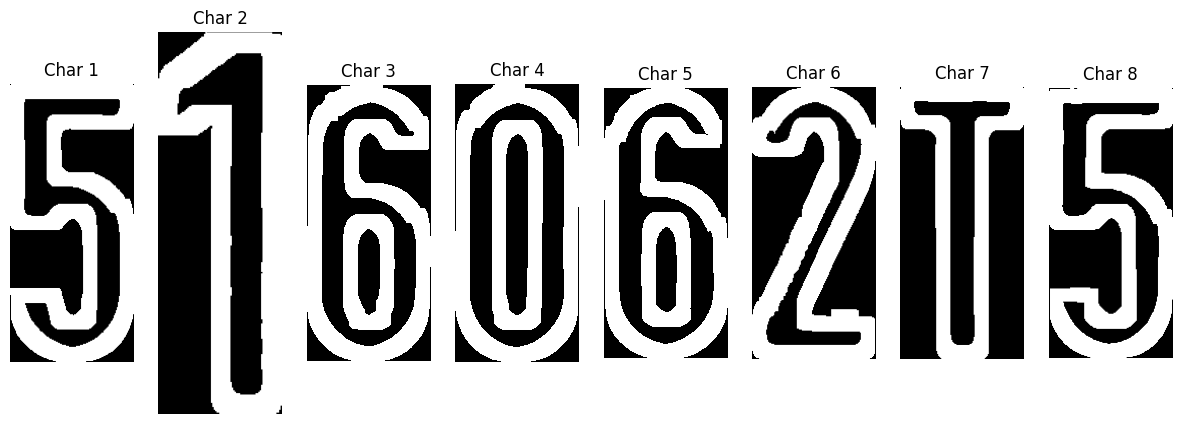

In [7]:
license_plate_img = cv2.imread('license_plate.jpg')
license_plate_gray = cv2.cvtColor(license_plate_img, cv2.COLOR_BGR2GRAY)
plt.imshow(license_plate_gray, cmap='gray')

# Preprocessing: Gaussian Blur
blurred = cv2.GaussianBlur(license_plate_gray, (5, 5), 0)

# Morphological Operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
closed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
gradient = cv2.morphologyEx(opened, cv2.MORPH_GRADIENT, kernel)

# Extract and Isolating
_, thresh = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw bounding boxes around characters
character_images = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if h > 30 and w > 10:  # Filter out small contours
        char_img = thresh[y:y+h, x:x+w]
        character_images.append(char_img)
        cv2.rectangle(license_plate_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
# Display processing steps & morphs
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.title('Original License Plate')
plt.imshow(license_plate_gray, cmap='gray')
plt.subplot(2, 3, 2)
plt.title('Blurred Image')
plt.imshow(blurred, cmap='gray')
plt.subplot(2, 3, 3)
plt.title('Closed Image')
plt.imshow(closed, cmap='gray')
plt.subplot(2, 3, 4)
plt.title('Opened Image')
plt.imshow(opened, cmap='gray')
plt.subplot(2, 3, 5)
plt.title('Gradient Image')
plt.imshow(gradient, cmap='gray')
plt.subplot(2, 3, 6)
plt.title('Thresholded Image')
plt.imshow(thresh, cmap='gray')
plt.show()

# Extra: Filter out abnormal character images by calculating mean width and height
widths = [img.shape[1] for img in character_images]
heights = [img.shape[0] for img in character_images]
mean_width = np.mean(widths)
mean_height = np.mean(heights)
filtered_character_images = []
for img in character_images:
    if (0.3 * mean_width < img.shape[1] < 1.5 * mean_width) and (0.5 * mean_height < img.shape[0] < 1.5 * mean_height):
        filtered_character_images.append(img)

        
# Display extracted characters in an image
num_chars = len(filtered_character_images)
plt.figure(figsize=(15, 5))
for i, char_img in enumerate(filtered_character_images):
    plt.subplot(1, num_chars, i + 1)
    plt.title(f'Char {i+1}')
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

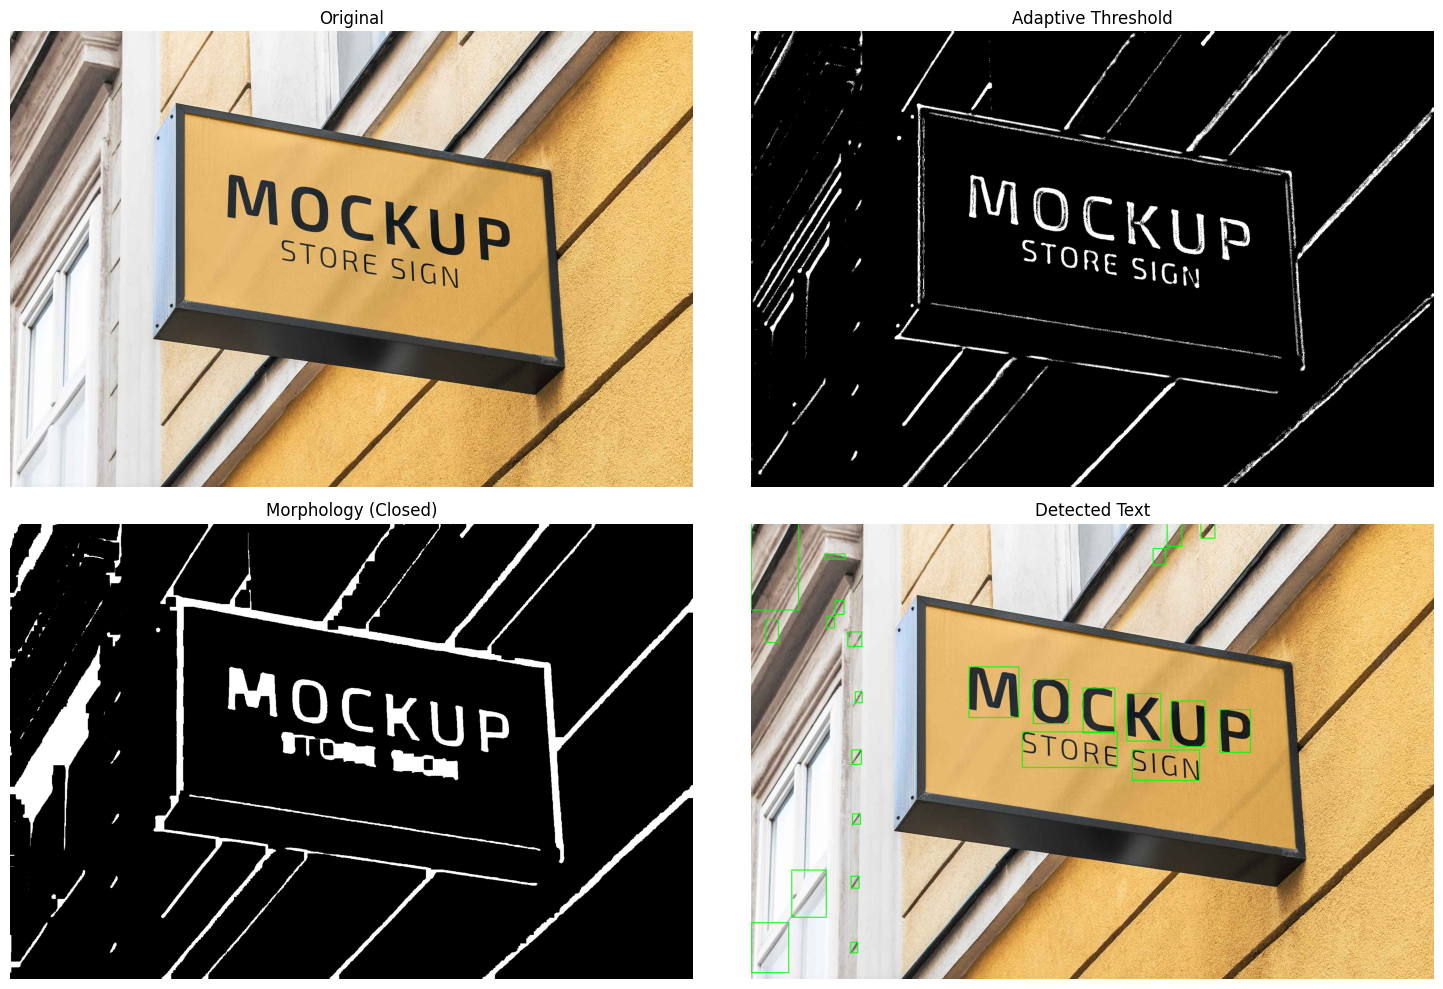

Detected 24 potential text regions.


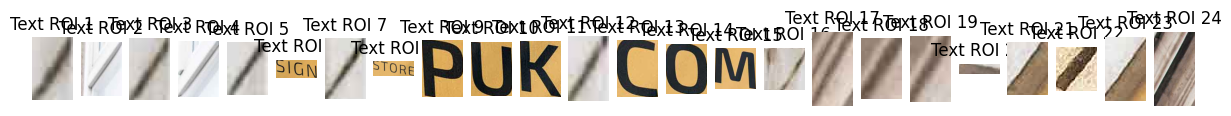

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_storefront_text(image_path):
    # --- Step 1: Load and Preprocess ---
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found.")
        return

    # Create a copy for visualization
    output = img.copy()
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian Blur to reduce high-frequency noise
    # (helps preventing the thresholding from spotting grain as text)
    blurred = cv2.GaussianBlur(gray, (35, 35), 0)

    # --- Step 2: Thresholding ---
    # We use Adaptive Thresholding because storefronts have uneven lighting (shadows vs. bright spots).
    # This calculates the threshold for small regions rather than one global value.
    thresh = cv2.adaptiveThreshold(
        blurred, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 11, 2
    )

    # --- Step 3: Morphology (The Core Task) ---
    # We want to connect characters into words. 
    # Since text is usually wider than it is tall, we use a rectangular kernel.
    
    # Kernel size (15, 3) means we look for horizontal connections.
    # Adjust this based on the resolution of your image.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
    
    # MORPH_CLOSE: Dilation followed by Erosion. 
    # This closes small gaps inside the foreground objects (connecting letters).
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # --- Step 4: Contour Detection & Filtering ---
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    detected_rois = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Calculate geometric metrics
        aspect_ratio = w / float(h)
        area = w * h
        
        # --- Heuristics to Identify Text ---
        # 1. Text is usually not a tiny speck (Area filter)
        # 2. Storefront text is usually horizontal (Aspect ratio > 1 typically, or within a range)
        # 3. Not the whole image (Upper area limit)
        if area > 500 and area < 50000 and aspect_ratio > 0.5:
            # Draw rectangle on original image
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
            # Extract the Region of Interest (ROI) - This is the "Segmentation"
            roi = img[y:y+h, x:x+w]
            detected_rois.append(roi)

    # --- Step 5: Visualization ---
    # Display the pipeline stages using Matplotlib
    plt.figure(figsize=(15, 10))

    titles = ['Original', 'Adaptive Threshold', 'Morphology (Closed)', 'Detected Text']
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), thresh, morph, cv2.cvtColor(output, cv2.COLOR_BGR2RGB)]

    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i], 'gray' if i in [1, 2] else None)
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Detected {len(detected_rois)} potential text regions.")
    
    # show extracted text regions
    if detected_rois:
        plt.figure(figsize=(15, 5))
        for i, roi in enumerate(detected_rois):
            plt.subplot(1, len(detected_rois), i + 1)
            plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
            plt.title(f'Text ROI {i+1}')
            plt.axis('off')
        plt.show()

# To run the pipeline, replace 'storefront.jpg' with your image path
detect_storefront_text('storefront.jpg')


Detected 29 text regions
Region 1: Position (0, 0), Size 122×219, Area 3537 pixels
Region 2: Position (36, 0), Size 111×203, Area 1173 pixels
Region 3: Position (437, 0), Size 163×242, Area 4020 pixels
Region 4: Position (1313, 0), Size 50×48, Area 1016 pixels
Region 5: Position (1382, 0), Size 189×230, Area 1107 pixels
Region 6: Position (1395, 39), Size 160×205, Area 2705 pixels
Region 7: Position (3, 152), Size 153×274, Area 1658 pixels
Region 8: Position (3, 318), Size 177×305, Area 1457 pixels
Region 9: Position (633, 416), Size 155×156, Area 8409 pixels
Region 10: Position (820, 451), Size 116×141, Area 3351 pixels
Region 11: Position (845, 471), Size 66×101, Area 2108 pixels
Region 12: Position (966, 476), Size 102×141, Area 4142 pixels
Region 13: Position (1096, 494), Size 108×147, Area 5260 pixels
Region 14: Position (1226, 516), Size 109×143, Area 5086 pixels
Region 15: Position (1368, 540), Size 99×134, Area 3311 pixels
Region 16: Position (130, 551), Size 105×433, Area 8447

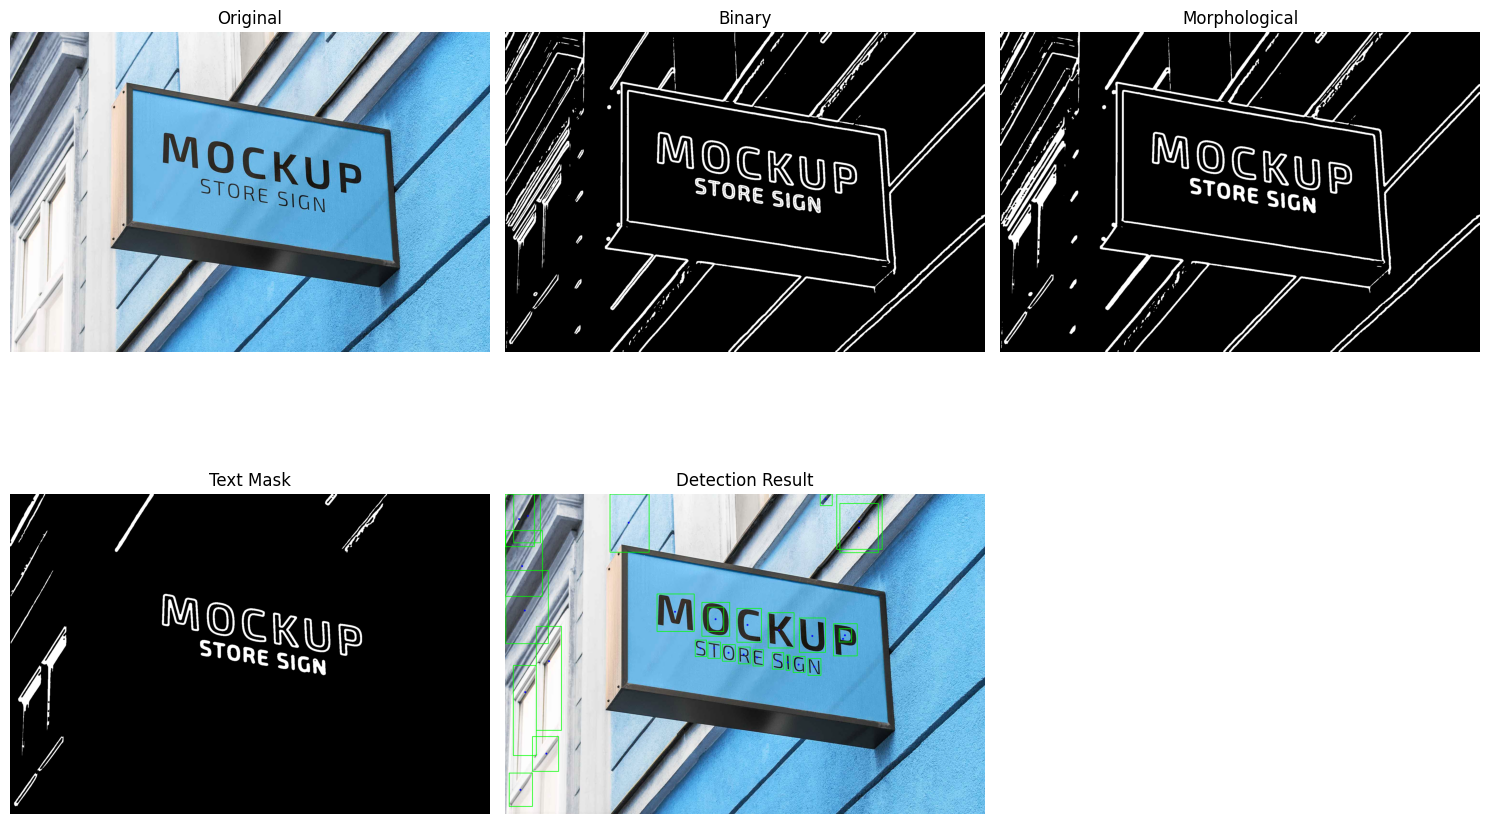

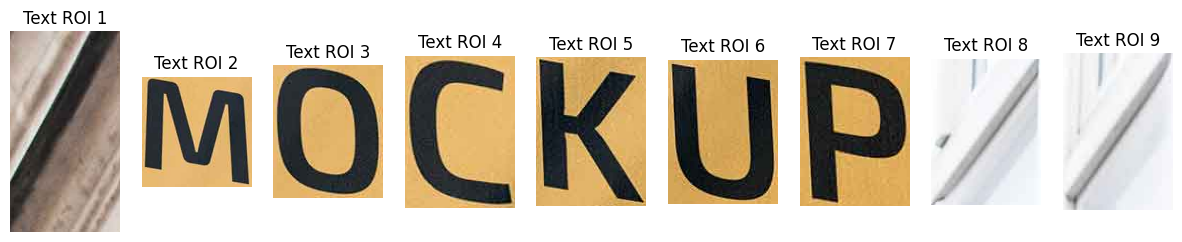

In [9]:
import cv2
import numpy as np

def detect_storefront_text(image_path, 
                          blur_kernel=(5,5),
                          morph_kernel_size=5,
                          min_area=300,
                          max_area=10000,
                          min_width=10,
                          max_width=200):
    """
    Complete pipeline for storefront text detection and segmentation.
    
    Args:
        image_path: Path to input storefront image
        blur_kernel: Gaussian blur kernel size (odd numbers)
        morph_kernel_size: Morphological operation kernel size
        min_area, max_area: Pixel area thresholds for text regions
        min_width, max_width: Width constraints for text detection
    
    Returns:
        Dictionary containing:
        - original: Input image
        - grayscale: Grayscale version
        - binary: Thresholded image
        - morphology: Post-morphological operations
        - labeled: Component labels visualization
        - text_mask: Final detected text regions
        - bounding_boxes: List of detected text region coordinates
    """
    
    # ===== STAGE 1-2: LOAD AND CONVERT TO GRAYSCALE =====
    original = cv2.imread(image_path)
    grayscale = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    
    # ===== STAGE 3: NOISE FILTERING =====
    blurred = cv2.GaussianBlur(grayscale, blur_kernel, 0)
    
    # ===== STAGE 4: MORPHOLOGICAL GRADIENT FOR EDGE DETECTION =====
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, 
                                       (morph_kernel_size, morph_kernel_size))
    dilated = cv2.dilate(blurred, kernel, iterations=1)
    eroded = cv2.erode(blurred, kernel, iterations=1)
    morphological_gradient = dilated - eroded
    
    # ===== STAGE 5: THRESHOLDING =====
    # Using Otsu's method for automatic threshold selection
    _, binary = cv2.threshold(morphological_gradient, 0, 255, 
                              cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # Alternative: Adaptive thresholding for variable lighting
    # binary = cv2.adaptiveThreshold(morphological_gradient, 255,
    #                                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    #                                cv2.THRESH_BINARY, 11, 2)
    
    # ===== STAGE 6: MORPHOLOGICAL CLEANUP =====
    # Close operation (dilate then erode) to fill gaps within text
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    morphological = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=1)
    
    # ===== STAGE 7: CONNECTED COMPONENT LABELING =====
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        morphological, connectivity=8, ltype=cv2.CV_32S)
    
    # ===== STAGE 8: TEXT REGION FILTERING & VERIFICATION =====
    text_mask = np.zeros(grayscale.shape, dtype="uint8")
    bounding_boxes = []
    
    # Skip label 0 (background)
    for i in range(1, num_labels):
        # Extract component statistics
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        
        # Apply filtering criteria
        if (min_area <= area <= max_area and 
            min_width <= width <= max_width and
            height > 5):  # Reasonable height
            
            # Create component mask and add to final text mask
            component_mask = (labels == i).astype("uint8") * 255
            text_mask = cv2.bitwise_or(text_mask, component_mask)
            
            # Store bounding box for output
            bounding_boxes.append({
                'x': x, 'y': y, 'width': width, 'height': height,
                'area': area, 'center': centroids[i]
            })
    
    # ===== CREATE VISUALIZATION =====
    # Draw bounding boxes on original image
    output_visualization = original.copy()
    for bbox in bounding_boxes:
        x, y, w, h = bbox['x'], bbox['y'], bbox['width'], bbox['height']
        cv2.rectangle(output_visualization, (x, y), (x + w, y + h), 
                     (0, 255, 0), 2)  # Green boxes
        # Draw centroid
        cx, cy = int(bbox['center'][0]), int(bbox['center'][1])
        cv2.circle(output_visualization, (cx, cy), 4, (0, 0, 255), -1)  # Red circle
    
    # Create labeled component visualization
    labeled_image = np.zeros((labels.shape[0], labels.shape[1], 3), dtype="uint8")
    unique_labels = np.unique(labels)
    colors = [tuple(np.random.randint(0, 256, 3)) for _ in range(len(unique_labels))]
    for label in unique_labels:
        if label == 0:
            continue
        mask = (labels == label).astype("uint8")
        labeled_image[mask > 0] = colors[label % len(colors)]
    
    return {
        'original': original,
        'grayscale': grayscale,
        'binary': binary,
        'morphology': morphological,
        'labeled': labeled_image,
        'text_mask': text_mask,
        'bounding_boxes': bounding_boxes,
        'visualization': output_visualization,
        'num_text_regions': len(bounding_boxes)
    }

# ===== USAGE EXAMPLE =====
if __name__ == "__main__":
    # Load and process storefront image
    results = detect_storefront_text("storefront.jpg",
                                     blur_kernel=(15,15),
                                     morph_kernel_size=5,
                                     min_area=750,
                                     max_area=10000)
    
    # Extract detected text information
    print(f"Detected {results['num_text_regions']} text regions")
    for i, bbox in enumerate(results['bounding_boxes']):
        print(f"Region {i+1}: Position ({bbox['x']}, {bbox['y']}), "
              f"Size {bbox['width']}×{bbox['height']}, Area {bbox['area']} pixels")
    
    # Display results
    plt.figure(figsize=(15, 10))
    titles = ['Original', 'Binary', 'Morphological', 'Text Mask', 'Detection Result']
    images = [results['original'], results['binary'], 
              results['morphology'], results['text_mask'], 
              results['visualization']]
    for i in range(5):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], 'gray' if i in [1, 2, 3] else None)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    detected_rois = []
    for bbox in results['bounding_boxes']:
        x, y, w, h = bbox['x'], bbox['y'], bbox['width'], bbox['height']
        roi = results['original'][y:y+h, x:x+w]
        detected_rois.append(roi)
    # filter out abnormal character images by calculating mean width x height
    areas = [roi.shape[0] * roi.shape[1] for roi in detected_rois]
    mean_area = np.mean(areas)
    filtered_rois = []
    for roi in detected_rois:
        area = roi.shape[0] * roi.shape[1]
        if 0.7 * mean_area < area < 1.5 * mean_area:
            filtered_rois.append(roi)
    detected_rois = filtered_rois
    
    # Display extracted text regions
    if detected_rois:
        plt.figure(figsize=(15, 5))
        for i, roi in enumerate(detected_rois):
            plt.subplot(1, len(detected_rois), i + 1)
            plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
            plt.title(f'Text ROI {i+1}')
            plt.axis('off')
        plt.show()
        
    


## 3. Image Inpainting

    (a) Mask Generation using Morphology + Diffusion-Based Inpainting

      - Use dilation, erosion, or morphological closing to generate a binary mask
      (e.g., detecting defects, noise, unwanted objects)

      - Apply diffusion-based inpainting and then using OpenCV's PDE-based Telea or NS method

      - Show:
        - Image
        - Mask
        - Final inpainted result
        - Discussion

    (b) Re-implement the method from the paper
    "Region Filling and Object Removal by Exemplar-Based Image Inpainting" (Criminisi et al., 2004)

      - Implement the exemplar-based pipeline:
        - Priority computation
        $$P(p)=C(p)D(p)$$
        - Patch search
        - Patch replacement
        - Update confidence map

      - Explain the full algorithm:
          - Confidence term
          - Data term (isophote direction)
          - Patch matching
          - Boundary filling strategy

      - Choose an image with missing regions or objects to remove
          → Compare your result vs OpenCV inpainting.

    (c) Implement One Additional Inpainting Method (Beyond the Above Two)
    Choose one of the following categories and implement one method:
    ```
        - Local Statistical Models
          - Gaussian Mixture Models (GMM)
          - Markov Random Fields (MRF)
        - Patch-Based Methods
          - PatchMatch
          - Texture synthesis methods
        - Sparse Representation / Dictionary Learning
          - K-SVD Inpainting
          - Wavelet / Curvelet / Shearlet domain inpainting
        - CNN-Based Inpainting
          - Partial Convolution
          - Gated Convolution
          - Context Encoder (AE-based)
        - GAN-Based Inpainting
          - DeepFill v1/v2
          - EdgeConnect
          - StructureFlow
        - Transformer-Based Inpainting
          - MAT (Masked Autoencoder Transformer)
          - ViT-Inpainting models
        - Diffusion-Based Inpainting (2022–2025)
          - LaMa
          - RePaint
          - Stable Diffusion Inpainting
          - DALL·E 2 / 3 inpainting
          - SDXL Inpainting
          - SDE-based diffusion inpainting
    ```
    - For your chosen method:
      - Explain the mathematical idea
      - Implement a working minimal example
      (Open-source models allowed)
      - Compare with exemplar-based and diffusion-inpainting

In [21]:
img = cv2.imread("clairobscur.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

H, W, C = img.shape


_, mask = cv2.threshold(img_gray, 160, 255, cv2.THRESH_BINARY_INV)

#tạo kernel 3x3
kernel = np.ones((3,3), np.uint8)

#chọn 1 trong 2
# mask = cv2.erode(mask, kernel, iterations=2)
mask = cv2.dilate(mask, kernel, iterations=2)

mask_bin = (mask > 0).astype(np.uint8)

inpainted_diff = img.copy()
num_iterations = 5

for _ in range(num_iterations):
    new_img = inpainted_diff.copy()
    for y in range(1, H-1):
        for x in range(1, W-1):
            if mask_bin[y, x] == 1:
                for c in range(C):
                    new_img[y, x, c] = np.mean([
                        inpainted_diff[y-1, x, c],
                        inpainted_diff[y+1, x, c],
                        inpainted_diff[y, x-1, c],
                        inpainted_diff[y, x+1, c]
                    ])
    inpainted_diff = new_img

#OPENCV
# Telea method
inpaint_telea = cv2.inpaint(
    img, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA
)

# Navier–Stokes method
inpaint_ns = cv2.inpaint(
    img, mask, inpaintRadius=3, flags=cv2.INPAINT_NS
)


fig, axs = plt.subplots(1, 5, figsize=(22, 5))

axs[0].imshow(img)
axs[0].set_title("Original")

axs[1].imshow(mask, cmap="gray")
axs[1].set_title("Mask")

axs[2].imshow(inpainted_diff)
axs[2].set_title("Diffusion-Based")

axs[3].imshow(inpaint_telea)
axs[3].set_title("OpenCV Telea")

axs[4].imshow(inpaint_ns)
axs[4].set_title("OpenCV Navier-Stokes")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Starting inpainting...
4003 pixels remaining...
3965 pixels remaining...
3920 pixels remaining...
3886 pixels remaining...
3862 pixels remaining...
3832 pixels remaining...
3802 pixels remaining...
3768 pixels remaining...
3738 pixels remaining...
3698 pixels remaining...
3668 pixels remaining...
3639 pixels remaining...
3603 pixels remaining...
3567 pixels remaining...
3527 pixels remaining...
3478 pixels remaining...
3443 pixels remaining...
3413 pixels remaining...
3382 pixels remaining...
3344 pixels remaining...
3296 pixels remaining...
3257 pixels remaining...
3225 pixels remaining...
3191 pixels remaining...
3153 pixels remaining...
3109 pixels remaining...
3076 pixels remaining...
3043 pixels remaining...
2994 pixels remaining...
2967 pixels remaining...
2922 pixels remaining...
2888 pixels remaining...
2849 pixels remaining...
2809 pixels remaining...
2767 pixels remaining...
2742 pixels remaining...
2713 pixels remaining...
2673 pixels remaining...
2634 pixels remaining...
26

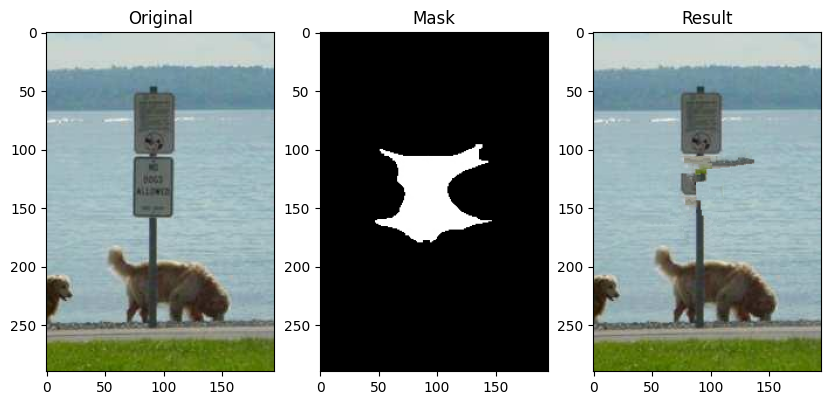

In [ ]:
class Inpainter:
    def __init__(self, image, mask, patch_size=9, plot_progress=False):
        self.image = image.astype('uint8')
        # FIX: Normalize mask to 0 and 1. Assumes 255 (white) is the hole to fill.
        self.mask = (mask > 127).astype('uint8') 
        self.patch_size = patch_size
        self.plot_progress = plot_progress


        self.working_image = None
        self.working_mask = None
        self.front = None
        self.confidence = None
        self.data = None
        self.priority = None

    def inpaint(self):
        """ Compute the new image and return it """
        self._validate_inputs()
        self._initialize_attributes()

        start_time = time.time()
        keep_going = True
        
        while keep_going:
            self._find_front()
            if self.plot_progress:
                self._plot_image()

            self._update_priority()

            target_pixel = self._find_highest_priority_pixel()
            find_start_time = time.time()
            source_patch = self._find_source_patch(target_pixel)
            
            # Simple logging
            # print('Time to find best: %f seconds' % (time.time()-find_start_time))

            self._update_image(target_pixel, source_patch)

            keep_going = not self._finished()

        print('Took %f seconds to complete' % (time.time() - start_time))
        return self.working_image

    def _validate_inputs(self):
        if self.image.shape[:2] != self.mask.shape:
            raise AttributeError('mask and image must be of the same size')

    def _plot_image(self):
        # Visualization logic
        height, width = self.working_mask.shape

        # Remove the target region from the image
        inverse_mask = 1 - self.working_mask
        rgb_inverse_mask = self._to_rgb(inverse_mask)
        image = self.working_image * rgb_inverse_mask

        # Fill the target borders with red
        if self.front is not None:
            image[:, :, 0] += self.front * 255

        # Fill the inside of the target region with white
        white_region = (self.working_mask - (self.front if self.front is not None else 0)) * 255
        rgb_white_region = self._to_rgb(white_region)
        image += rgb_white_region

        plt.clf()
        plt.imshow(image.astype('uint8'))
        plt.title("Inpainting Progress")
        plt.draw()
        plt.pause(0.001)

    def _initialize_attributes(self):
        """ Initialize the non initialized attributes
        The confidence is initially the inverse of the mask, that is, the
        target region is 0 and source region is 1.
        """
        height, width = self.image.shape[:2]

        self.confidence = (1 - self.mask).astype(float)
        self.data = np.zeros([height, width])

        self.working_image = np.copy(self.image)
        self.working_mask = np.copy(self.mask)

    def _find_front(self):
        """ Find the front using laplacian on the mask """
        self.front = (laplace(self.working_mask) > 0).astype('uint8')

    def _update_priority(self):
        self._update_confidence()
        self._update_data()
        self.priority = self.confidence * self.data * self.front

    def _update_confidence(self):
        new_confidence = np.copy(self.confidence)
        front_positions = np.argwhere(self.front == 1)
        for point in front_positions:
            patch = self._get_patch(point)
            new_confidence[point[0], point[1]] = sum(sum(
                self._patch_data(self.confidence, patch)
            ))/self._patch_area(patch)

        self.confidence = new_confidence

    def _update_data(self):
        normal = self._calc_normal_matrix()
        gradient = self._calc_gradient_matrix()

        normal_gradient = normal*gradient
        self.data = np.sqrt(
            normal_gradient[:, :, 0]**2 + normal_gradient[:, :, 1]**2
        ) + 0.001  # To be sure to have a greater than 0 data

    def _calc_normal_matrix(self):
        x_kernel = np.array([[.25, 0, -.25], [.5, 0, -.5], [.25, 0, -.25]])
        y_kernel = np.array([[-.25, -.5, -.25], [0, 0, 0], [.25, .5, .25]])

        x_normal = convolve(self.working_mask.astype(float), x_kernel)
        y_normal = convolve(self.working_mask.astype(float), y_kernel)
        normal = np.dstack((x_normal, y_normal))

        height, width = normal.shape[:2]
        norm = np.sqrt(y_normal**2 + x_normal**2) \
                 .reshape(height, width, 1) \
                 .repeat(2, axis=2)
        norm[norm == 0] = 1

        unit_normal = normal/norm
        return unit_normal

    def _calc_gradient_matrix(self):
        height, width = self.working_image.shape[:2]

        # Use skimage's rgb2gray
        grey_image = rgb2gray(self.working_image)
        # Handle the hole (mask=1) by setting it to None/Nan or masking it out
        # This implementation simply calculates gradient over everything
        
        gradient = np.nan_to_num(np.array(np.gradient(grey_image)))
        gradient_val = np.sqrt(gradient[0]**2 + gradient[1]**2)
        max_gradient = np.zeros([height, width, 2])

        front_positions = np.argwhere(self.front == 1)
        for point in front_positions:
            patch = self._get_patch(point)
            patch_y_gradient = self._patch_data(gradient[0], patch)
            patch_x_gradient = self._patch_data(gradient[1], patch)
            patch_gradient_val = self._patch_data(gradient_val, patch)

            patch_max_pos = np.unravel_index(
                patch_gradient_val.argmax(),
                patch_gradient_val.shape
            )

            max_gradient[point[0], point[1], 0] = \
                patch_y_gradient[patch_max_pos]
            max_gradient[point[0], point[1], 1] = \
                patch_x_gradient[patch_max_pos]

        return max_gradient

    def _find_highest_priority_pixel(self):
        point = np.unravel_index(self.priority.argmax(), self.priority.shape)
        return point

    def _find_source_patch(self, target_pixel):
        target_patch = self._get_patch(target_pixel)
        height, width = self.working_image.shape[:2]
        patch_height, patch_width = self._patch_shape(target_patch)

        best_match = None
        best_match_difference = 0

        # Use skimage's rgb2lab
        lab_image = rgb2lab(self.working_image)

        # Optimization: Don't iterate every single pixel if image is huge
        # You can add a 'stride' here to speed up e.g. range(0, ..., step=5)
        for y in range(0, height - patch_height + 1):
            for x in range(0, width - patch_width + 1):
                source_patch = [
                    [y, y + patch_height-1],
                    [x, x + patch_width-1]
                ]
                
                # If the source patch touches the hole (mask=1), skip it
                if self._patch_data(self.working_mask, source_patch).sum() != 0:
                    continue

                difference = self._calc_patch_difference(
                    lab_image,
                    target_patch,
                    source_patch
                )

                if best_match is None or difference < best_match_difference:
                    best_match = source_patch
                    best_match_difference = difference
        return best_match

    def _update_image(self, target_pixel, source_patch):
        target_patch = self._get_patch(target_pixel)
        
        # Find pixels in the target patch that are part of the hole (mask==1)
        pixels_positions = np.argwhere(
            self._patch_data(
                self.working_mask,
                target_patch
            ) == 1
        ) + [target_patch[0][0], target_patch[1][0]]
        
        patch_confidence = self.confidence[target_pixel[0], target_pixel[1]]
        
        for point in pixels_positions:
            self.confidence[point[0], point[1]] = patch_confidence

        mask = self._patch_data(self.working_mask, target_patch)
        rgb_mask = self._to_rgb(mask)
        source_data = self._patch_data(self.working_image, source_patch)
        target_data = self._patch_data(self.working_image, target_patch)

        new_data = source_data*rgb_mask + target_data*(1-rgb_mask)

        self._copy_to_patch(
            self.working_image,
            target_patch,
            new_data
        )
        self._copy_to_patch(
            self.working_mask,
            target_patch,
            0
        )

    def _get_patch(self, point):
        half_patch_size = (self.patch_size-1)//2
        height, width = self.working_image.shape[:2]
        patch = [
            [
                max(0, point[0] - half_patch_size),
                min(point[0] + half_patch_size, height-1)
            ],
            [
                max(0, point[1] - half_patch_size),
                min(point[1] + half_patch_size, width-1)
            ]
        ]
        return patch

    def _calc_patch_difference(self, image, target_patch, source_patch):
        mask = 1 - self._patch_data(self.working_mask, target_patch)
        rgb_mask = self._to_rgb(mask)
        target_data = self._patch_data(
            image,
            target_patch
        ) * rgb_mask
        source_data = self._patch_data(
            image,
            source_patch
        ) * rgb_mask
        
        squared_distance = ((target_data - source_data)**2).sum()
        
        # Tie-breaker factor (Euclidean distance between patch coords)
        euclidean_distance = np.sqrt(
            (target_patch[0][0] - source_patch[0][0])**2 +
            (target_patch[1][0] - source_patch[1][0])**2
        ) 
        return squared_distance + euclidean_distance

    def _finished(self):
        height, width = self.working_image.shape[:2]
        remaining = self.working_mask.sum()
        total = height * width
        print('%d pixels remaining...' % (remaining))
        return remaining == 0

    @staticmethod
    def _patch_area(patch):
        return (1+patch[0][1]-patch[0][0]) * (1+patch[1][1]-patch[1][0])

    @staticmethod
    def _patch_shape(patch):
        return (1+patch[0][1]-patch[0][0]), (1+patch[1][1]-patch[1][0])

    @staticmethod
    def _patch_data(source, patch):
        return source[
            patch[0][0]:patch[0][1]+1,
            patch[1][0]:patch[1][1]+1
        ]

    @staticmethod
    def _copy_to_patch(dest, dest_patch, data):
        dest[
            dest_patch[0][0]:dest_patch[0][1]+1,
            dest_patch[1][0]:dest_patch[1][1]+1
        ] = data

    @staticmethod
    def _to_rgb(image):
        height, width = image.shape
        return image.reshape(height, width, 1).repeat(3, axis=2)


# --- Example Usage ---
if __name__ == "__main__":
    # Create a dummy image if files don't exist
    # (A red square with a hole in the middle)
    img = cv2.imread('image.jpg')
    mask = cv2.imread('mask.jpg', cv2.IMREAD_GRAYSCALE)

    # Example configuration variables
    PATCH_SIZE = 9
    PLOT_PROGRESS = False  # Set to True to see animation

    print("Starting inpainting...")
    output_image = Inpainter(
        img,
        mask,
        patch_size=PATCH_SIZE,
        plot_progress=PLOT_PROGRESS
    ).inpaint()

    # Display final result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title('Original')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.subplot(1, 3, 2)
    plt.title('Mask')
    plt.imshow(mask, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title('Result')
    plt.imshow(cv2.cvtColor(output_image.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.show()

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5


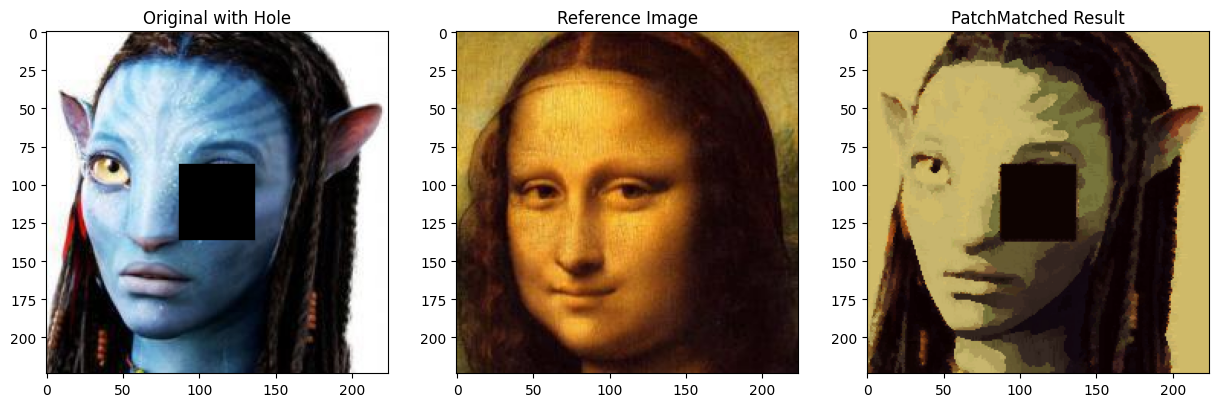

In [18]:
import numpy as np
import cv2

def cal_distance(a, b, A_padding, B, p_size):
    p = p_size // 2
    # patch_a comes from A_padding (which is float and contains NaNs)
    patch_a = A_padding[a[0]:a[0]+p_size, a[1]:a[1]+p_size, :]
    # patch_b comes from B (ref image), ensure it's float for subtraction
    patch_b = B[b[0]-p:b[0]+p+1, b[1]-p:b[1]+p+1, :].astype(float)
    
    temp = patch_b - patch_a
    
    # Count valid (non-NaN) pixels
    is_nan_mask = np.isnan(temp)
    num = np.sum(1 - np.int32(is_nan_mask))
    
    # Avoid division by zero if patch is completely empty (all NaNs)
    if num == 0:
        return float('inf')
        
    dist = np.sum(np.square(np.nan_to_num(temp))) / num
    return dist

def reconstruction(f, A, B):
    A_h = np.size(A, 0)
    A_w = np.size(A, 1)
    temp = np.zeros_like(A)
    
    for i in range(A_h):
        for j in range(A_w):
            # Look up the corresponding pixel in B based on the NNF 'f'
            coord = f[i, j]
            temp[i, j, :] = B[coord[0], coord[1], :]
            
    # Convert back to uint8 for OpenCV display
    result_img = temp.astype(np.uint8)
    
    cv2.imshow("Reconstruction", result_img)
    cv2.waitKey(1) # Refresh window
    return result_img

def initialization(A, B, p_size):
    A_h = np.size(A, 0)
    A_w = np.size(A, 1)
    B_h = np.size(B, 0)
    B_w = np.size(B, 1)
    p = p_size // 2
    
    random_B_r = np.random.randint(p, B_h-p, [A_h, A_w])
    random_B_c = np.random.randint(p, B_w-p, [A_h, A_w])
    
    # Padding with NaNs
    A_padding = np.ones([A_h+p*2, A_w+p*2, 3]) * np.nan
    A_padding[p:A_h+p, p:A_w+p, :] = A
    
    f = np.zeros([A_h, A_w], dtype=object)
    dist = np.zeros([A_h, A_w])
    
    for i in range(A_h):
        for j in range(A_w):
            a = np.array([i, j])
            b = np.array([random_B_r[i, j], random_B_c[i, j]], dtype=np.int32)
            f[i, j] = b
            dist[i, j] = cal_distance(a, b, A_padding, B, p_size)
            
    return f, dist, A_padding

def propagation(f, a, dist, A_padding, B, p_size, is_odd):
    A_h = np.size(A_padding, 0) - p_size + 1
    A_w = np.size(A_padding, 1) - p_size + 1
    x = a[0]
    y = a[1]
    
    if is_odd:
        d_left = dist[max(x-1, 0), y]
        d_up = dist[x, max(y-1, 0)]
        d_current = dist[x, y]
        idx = np.argmin(np.array([d_current, d_left, d_up]))
        
        if idx == 1:
            f[x, y] = f[max(x - 1, 0), y]
            dist[x, y] = cal_distance(a, f[x, y], A_padding, B, p_size)
        if idx == 2:
            f[x, y] = f[x, max(y - 1, 0)]
            dist[x, y] = cal_distance(a, f[x, y], A_padding, B, p_size)
    else:
        d_right = dist[min(x + 1, A_h-1), y]
        d_down = dist[x, min(y + 1, A_w-1)]
        d_current = dist[x, y]
        idx = np.argmin(np.array([d_current, d_right, d_down]))
        
        if idx == 1:
            f[x, y] = f[min(x + 1, A_h-1), y]
            dist[x, y] = cal_distance(a, f[x, y], A_padding, B, p_size)
        if idx == 2:
            f[x, y] = f[x, min(y + 1, A_w-1)]
            dist[x, y] = cal_distance(a, f[x, y], A_padding, B, p_size)

def random_search(f, a, dist, A_padding, B, p_size, alpha=0.5):
    x = a[0]
    y = a[1]
    B_h = np.size(B, 0)
    B_w = np.size(B, 1)
    p = p_size // 2
    i = 4
    search_h = B_h * alpha ** i
    search_w = B_w * alpha ** i
    b_x = f[x, y][0]
    b_y = f[x, y][1]
    
    while search_h > 1 and search_w > 1:
        search_min_r = max(b_x - int(search_h), p)
        search_max_r = min(b_x + int(search_h), B_h-p)
        if search_max_r <= search_min_r: break # Safety check
            
        random_b_x = np.random.randint(search_min_r, search_max_r)
        
        search_min_c = max(b_y - int(search_w), p)
        search_max_c = min(b_y + int(search_w), B_w - p)
        if search_max_c <= search_min_c: break # Safety check
            
        random_b_y = np.random.randint(search_min_c, search_max_c)
        
        search_h = B_h * alpha ** i
        search_w = B_w * alpha ** i
        b = np.array([random_b_x, random_b_y])
        d = cal_distance(a, b, A_padding, B, p_size)
        
        if d < dist[x, y]:
            dist[x, y] = d
            f[x, y] = b
        i += 1

def NNS(img, ref, p_size, itr):
    A_h = np.size(img, 0)
    A_w = np.size(img, 1)
    
    # Ensure input image is float for NaN handling during initialization
    f, dist, img_padding = initialization(img.astype(float), ref, p_size)
    
    for iteration in range(1, itr+1):
        print(f"Iteration: {iteration}")
        if iteration % 2 == 0:
            for i in range(A_h - 1, -1, -1):
                for j in range(A_w - 1, -1, -1):
                    a = np.array([i, j])
                    propagation(f, a, dist, img_padding, ref, p_size, False)
                    random_search(f, a, dist, img_padding, ref, p_size)
        else:
            for i in range(A_h):
                for j in range(A_w):
                    a = np.array([i, j])
                    propagation(f, a, dist, img_padding, ref, p_size, True)
                    random_search(f, a, dist, img_padding, ref, p_size)
        
        # # Visualize progress
        # reconstruction(f, img, ref)
        
    return f

# # --- Main Execution Block ---
# if __name__ == "__main__":
#     # Load images
#     # NOTE: Ensure 'image.jpg' and 'reference.jpg' exist. 
#     # For testing, we can use the same image for both.
#     orig_img = cv2.imread('input.jpg')
#     ref_img = cv2.imread('ref.jpg') # Using same image as reference for demo

#     if orig_img is None:
#         print("Error: Image not found. Creating a dummy image.")
#         orig_img = np.random.randint(0, 255, (200, 200, 3), dtype=np.uint8)
#         ref_img = orig_img.copy()

#     # 1. Create a Mask/Hole in the image (simulate missing data)
#     # We convert to float so we can insert NaNs
#     img_with_hole = orig_img.astype(float)
    
#     # Create a hole in the center (50x50 pixels)
#     h, w = img_with_hole.shape[:2]
#     img_with_hole[h//2-25:h//2+25, w//2-25:w//2+25, :] = np.nan

#     # Display the corrupt input
#     show_input = img_with_hole.copy()
#     show_input[np.isnan(show_input)] = 0 # Show hole as black
#     cv2.imshow("Input with Hole", show_input.astype(np.uint8))

#     # 2. Run PatchMatch / NNS
#     print("Running NNS...")
#     final_field = NNS(img_with_hole, ref_img, p_size=3, itr=5)

#     # 3. Final Result
#     final_res = reconstruction(final_field, img_with_hole, ref_img)
#     cv2.imshow("Final Result", final_res)
    
#     print("Done. Press any key to exit.")
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

orig_img = cv2.imread('input.jpg')
ref_img = cv2.imread('ref.jpg') 

orig_img_hole = orig_img.copy()
h, w = orig_img_hole.shape[:2]
orig_img_hole[h//2-25:h//2+25, w//2-25:w//2+25, :] = 0 # Black hole

patchmactched_img = NNS(orig_img_hole, ref_img, p_size=3, itr=5)
patchmactched_img = reconstruction(patchmactched_img, orig_img_hole, ref_img)

# Display final result
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('Original with Hole')
plt.imshow(cv2.cvtColor(orig_img_hole, cv2.COLOR_BGR2RGB))
plt.subplot(1, 3, 2)
plt.title('Reference Image')
plt.imshow(cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 3, 3)
plt.title('PatchMatched Result')
plt.imshow(cv2.cvtColor(patchmactched_img, cv2.COLOR_BGR2RGB))
plt.show()

Initializing NND...
Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10


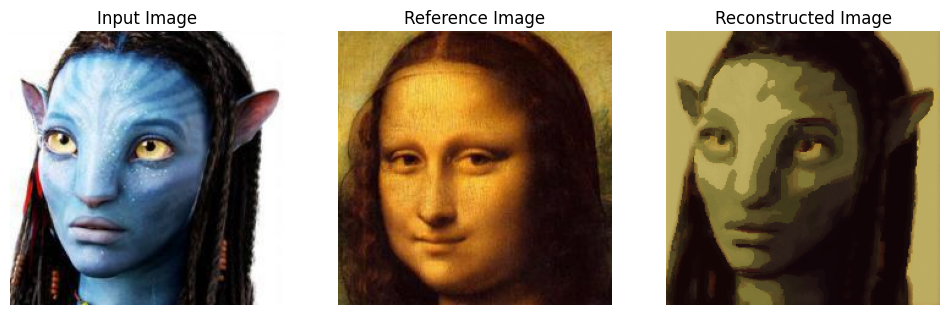

In [19]:

def normalize(F_L):
    # Avoid division by zero
    norm = np.sqrt(np.sum(np.square(F_L)))
    if norm == 0:
        return F_L
    return F_L / norm

def cal_distance(A, B, A_prime, B_prime, a_x, a_y, b_x, b_y, patch_size):
    A_H, A_W = A.shape[:2]
    B_H, B_W = B.shape[:2]
    
    dx0 = dy0 = patch_size // 2
    dx1 = dy1 = patch_size // 2 + 1
    
    # Boundary checks to extract valid patch regions
    dx0_valid = min(a_x, b_x, dx0)
    dx1_valid = min(A_H - a_x, B_H - b_x, dx1)
    dy0_valid = min(a_y, b_y, dy0)
    dy1_valid = min(A_W - a_y, B_W - b_y, dy1)
    
    patch_A = A[a_x - dx0_valid : a_x + dx1_valid, a_y - dy0_valid : a_y + dy1_valid]
    patch_A_prime = A_prime[a_x - dx0_valid : a_x + dx1_valid, a_y - dy0_valid : a_y + dy1_valid]
    patch_B = B[b_x - dx0_valid : b_x + dx1_valid, b_y - dy0_valid : b_y + dy1_valid]
    patch_B_prime = B_prime[b_x - dx0_valid : b_x + dx1_valid, b_y - dy0_valid : b_y + dy1_valid]
    
    num_pixels = (dx0_valid + dx1_valid) * (dy0_valid + dy1_valid)
    
    # Using float32 inputs prevents overflow here
    ssd_A = np.sum((patch_A - patch_B) ** 2)
    ssd_A_prime = np.sum((patch_A_prime - patch_B_prime) ** 2)
    
    dist = (ssd_A + ssd_A_prime) / num_pixels
    return dist

def init_nnf(A, B):
    A_H, A_W = A.shape[:2]
    B_H, B_W = B.shape[:2]
    nnf = np.zeros([A_H, A_W, 2], dtype=np.int32)
    nnf[:, :, 0] = np.random.randint(0, B_H, size=[A_H, A_W])
    nnf[:, :, 1] = np.random.randint(0, B_W, size=[A_H, A_W])
    return nnf

def init_nnd(A, B, A_prime, B_prime, SHAPE, nnf, patch_size):
    A_H, A_W = SHAPE[0], SHAPE[1]
    dist = np.zeros([A_H, A_W])
    for i in range(A_H):
        for j in range(A_W):
            dist[i, j] = cal_distance(A, B, A_prime, B_prime, i, j, nnf[i, j, 0], nnf[i, j, 1], patch_size)
    return dist

def propagation(A, B, A_prime, B_prime, SHAPE, a_x, a_y, nnf, nnd, patch_size, is_odd):
    A_H, A_W = SHAPE[0], SHAPE[1]
    B_H, B_W = SHAPE[2], SHAPE[3]
    
    d_best = nnd[a_x, a_y]
    best_b_x, best_b_y = nnf[a_x, a_y]

    if is_odd:
        # Check Left
        if a_y - 1 >= 0:
            b_x = nnf[a_x, a_y - 1, 0]
            b_y = nnf[a_x, a_y - 1, 1] + 1
            if b_y < B_W:
                dist = cal_distance(A, B, A_prime, B_prime, a_x, a_y, b_x, b_y, patch_size)
                if dist < d_best:
                    best_b_x, best_b_y, d_best = b_x, b_y, dist
        # Check Up
        if a_x - 1 >= 0:
            b_x = nnf[a_x - 1, a_y, 0] + 1
            b_y = nnf[a_x - 1, a_y, 1]
            if b_x < B_H:
                dist = cal_distance(A, B, A_prime, B_prime, a_x, a_y, b_x, b_y, patch_size)
                if dist < d_best:
                    best_b_x, best_b_y, d_best = b_x, b_y, dist
    else:
        # Check Right
        if a_y + 1 < A_W:
            b_x = nnf[a_x, a_y + 1, 0]
            b_y = nnf[a_x, a_y + 1, 1] - 1
            if b_y >= 0:
                dist = cal_distance(A, B, A_prime, B_prime, a_x, a_y, b_x, b_y, patch_size)
                if dist < d_best:
                    best_b_x, best_b_y, d_best = b_x, b_y, dist
        # Check Down
        if a_x + 1 < A_H:
            b_x = nnf[a_x + 1, a_y, 0] - 1
            b_y = nnf[a_x + 1, a_y, 1]
            if b_x >= 0:
                dist = cal_distance(A, B, A_prime, B_prime, a_x, a_y, b_x, b_y, patch_size)
                if dist < d_best:
                    best_b_x, best_b_y, d_best = b_x, b_y, dist

    nnf[a_x, a_y] = [best_b_x, best_b_y]
    nnd[a_x, a_y] = d_best
    return nnf, nnd

def random_search(A, B, A_prime, B_prime, SHAPE, a_x, a_y, nnf, nnd, search_radius, patch_size):
    B_H, B_W = SHAPE[2], SHAPE[3]
    best_b_x, best_b_y = nnf[a_x, a_y]
    best_dist = nnd[a_x, a_y]
    
    while search_radius >= 1:
        start_x = max(best_b_x - int(search_radius), 0)
        end_x = min(best_b_x + int(search_radius) + 1, B_H)
        start_y = max(best_b_y - int(search_radius), 0)
        end_y = min(best_b_y + int(search_radius) + 1, B_W)
        
        # Safety check for empty ranges
        if start_x >= end_x or start_y >= end_y:
            search_radius /= 2
            continue

        b_x = np.random.randint(start_x, end_x)
        b_y = np.random.randint(start_y, end_y)
        
        dist = cal_distance(A, B, A_prime, B_prime, a_x, a_y, b_x, b_y, patch_size)
        if dist < best_dist:
            best_dist = dist
            best_b_x = b_x
            best_b_y = b_y
        
        search_radius /= 2
        
    nnf[a_x, a_y] = [best_b_x, best_b_y]
    nnd[a_x, a_y] = best_dist
    return nnf, nnd

def NNF_Search(A, B, A_prime, B_prime, nnf, patch_size, itrs, search_radius):
    A = normalize(A)
    B = normalize(B)
    A_prime = normalize(A_prime)
    B_prime = normalize(B_prime)
    
    A_H, A_W = A.shape[:2]
    B_H, B_W = B.shape[:2]
    SHAPE = [A_H, A_W, B_H, B_W]
    
    print("Initializing NND...")
    nnd = init_nnd(A, B, A_prime, B_prime, SHAPE, nnf, patch_size)
    
    for itr in range(1, itrs + 1):
        print(f"Iteration {itr}/{itrs}")
        if itr % 2 == 0:
            for i in range(A_H - 1, -1, -1):
                for j in range(A_W - 1, -1, -1):
                    nnf, nnd = propagation(A, B, A_prime, B_prime, SHAPE, i, j, nnf, nnd, patch_size, False)
                    nnf, nnd = random_search(A, B, A_prime, B_prime, SHAPE, i, j, nnf, nnd, search_radius, patch_size)
        else:
            for i in range(A_H):
                for j in range(A_W):
                    nnf, nnd = propagation(A, B, A_prime, B_prime, SHAPE, i, j, nnf, nnd, patch_size, True)
                    nnf, nnd = random_search(A, B, A_prime, B_prime, SHAPE, i, j, nnf, nnd, search_radius, patch_size)
    return nnf

def warp(f, B):
    A_h = np.size(f, 0)
    A_w = np.size(f, 1)
    # Handle both grayscale (2D) and color (3D) images
    if len(B.shape) == 3:
        A_c = B.shape[2]
        temp = np.zeros([A_h, A_w, A_c])
        for i in range(A_h):
            for j in range(A_w):
                temp[i, j, :] = B[f[i, j][0], f[i, j][1], :]
    else:
        temp = np.zeros([A_h, A_w])
        for i in range(A_h):
            for j in range(A_w):
                temp[i, j] = B[f[i, j][0], f[i, j][1]]
    return temp

def reconstruction_avg(nnf, B, patch_size):
    A_h, A_w = nnf.shape[:2]
    B_h, B_w = B.shape[:2]
    
    is_color = len(B.shape) == 3
    if is_color:
        A_c = B.shape[2]
        rec = np.zeros([A_h, A_w, A_c])
    else:
        rec = np.zeros([A_h, A_w])

    x0 = y0 = patch_size // 2
    x1 = y1 = patch_size // 2 + 1
    
    for i in range(A_h):
        for j in range(A_w):
            b_x, b_y = nnf[i, j]
            
            start_x = max(b_x - x0, 0)
            end_x = min(b_x + x1, B_h)
            start_y = max(b_y - y0, 0)
            end_y = min(b_y + y1, B_w)
            
            if is_color:
                rec[i, j, :] = np.mean(B[start_x:end_x, start_y:end_y, :], axis=(0, 1))
            else:
                rec[i, j] = np.mean(B[start_x:end_x, start_y:end_y])
                
    return rec

def upsample_nnf(nnf, size):
    """
    Upsample NNF based on size using Nearest Neighbor.
    Corrected for OpenCV and numpy types.
    """
    small_h, small_w = nnf.shape[:2]
    # Calculate scale factors
    fy = size[0] / small_h
    fx = size[1] / small_w

    # Create 3-channel map for resizing: (x, y, dummy)
    temp_map = np.zeros((small_h, small_w, 3), dtype=np.float32)
    temp_map[..., 0] = nnf[..., 0]
    temp_map[..., 1] = nnf[..., 1]

    # Resize using Nearest Neighbor to preserve integer indices
    upsampled_map = cv2.resize(temp_map, (size[1], size[0]), interpolation=cv2.INTER_NEAREST)

    # Scale the indices to point to the correct new locations
    img = np.zeros((size[0], size[1], 2), dtype=np.int32)
    img[..., 0] = upsampled_map[..., 0] * fy
    img[..., 1] = upsampled_map[..., 1] * fx

    return img

input_img = cv2.imread('input.jpg')
ref_img = cv2.imread('ref.jpg')
if input_img is None or ref_img is None:
    print("Error: Input or reference image not found.")
    exit(1)
input_img = input_img.astype(np.float32) / 255.0
ref_img = ref_img.astype(np.float32) / 255.0
patch_size = 7
nnf = init_nnf(input_img, ref_img)
nnf = NNF_Search(input_img, ref_img, input_img, ref_img, nnf, patch_size, itrs=10, search_radius=32)
reconstructed_img = reconstruction_avg(nnf, ref_img, patch_size)

# Display the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Input Image')
plt.imshow(cv2.cvtColor((input_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Reference Image')
plt.imshow(cv2.cvtColor((ref_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Reconstructed Image')
plt.imshow(cv2.cvtColor((reconstructed_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

